In [ ]:
import pandas as pd
df = pd.read_csv('smart_meter_data.csv')
df.head()

,datetime,msn,location,daily_consumption_load,energy_supplied,energy_billed
0,2021-01-01 00:00:00,ACE43B7D,Chennai,2.59,2.78,2.57
1,2021-01-01 00:15:00,ACE43B7D,Chennai,1.78,2.12,1.86
2,2021-01-01 00:30:00,ACE43B7D,Chennai,2.59,2.68,2.52
3,2021-01-01 00:45:00,ACE43B7D,Chennai,2.45,2.56,2.50
4,2021-01-01 01:00:00,ACE43B7D,Chennai,1.48,1.56,1.49


In [ ]:
df['date'] = df['datetime']

In [31]:
df['date'] = df['datetime'].dt.date
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year
df['day'] = df['datetime'].dt.day

In [33]:
daily_avg = df.groupby('date')['daily_consumption_load'].mean().reset_index()
daily_avg['date'] = pd.to_datetime(daily_avg['date'])

# Extract day and month for plotting
daily_avg['day_month'] = daily_avg['date'].dt.strftime('%d/%m')

print("Daily Average Consumption:")
print(daily_avg.head(10))

Daily Average Consumption:
        date  daily_consumption_load day_month
0 2021-01-01                2.472375     01/01
1 2021-01-02                2.546312     02/01
2 2021-01-03                2.594313     03/01
3 2021-01-04                2.566542     04/01
4 2021-01-05                2.590438     05/01
5 2021-01-06                2.479583     06/01
6 2021-01-07                2.597625     07/01
7 2021-01-08                2.508188     08/01
8 2021-01-09                2.500083     09/01
9 2021-01-10                2.572958     10/01


In [35]:
earlydata = daily_avg.head(100)

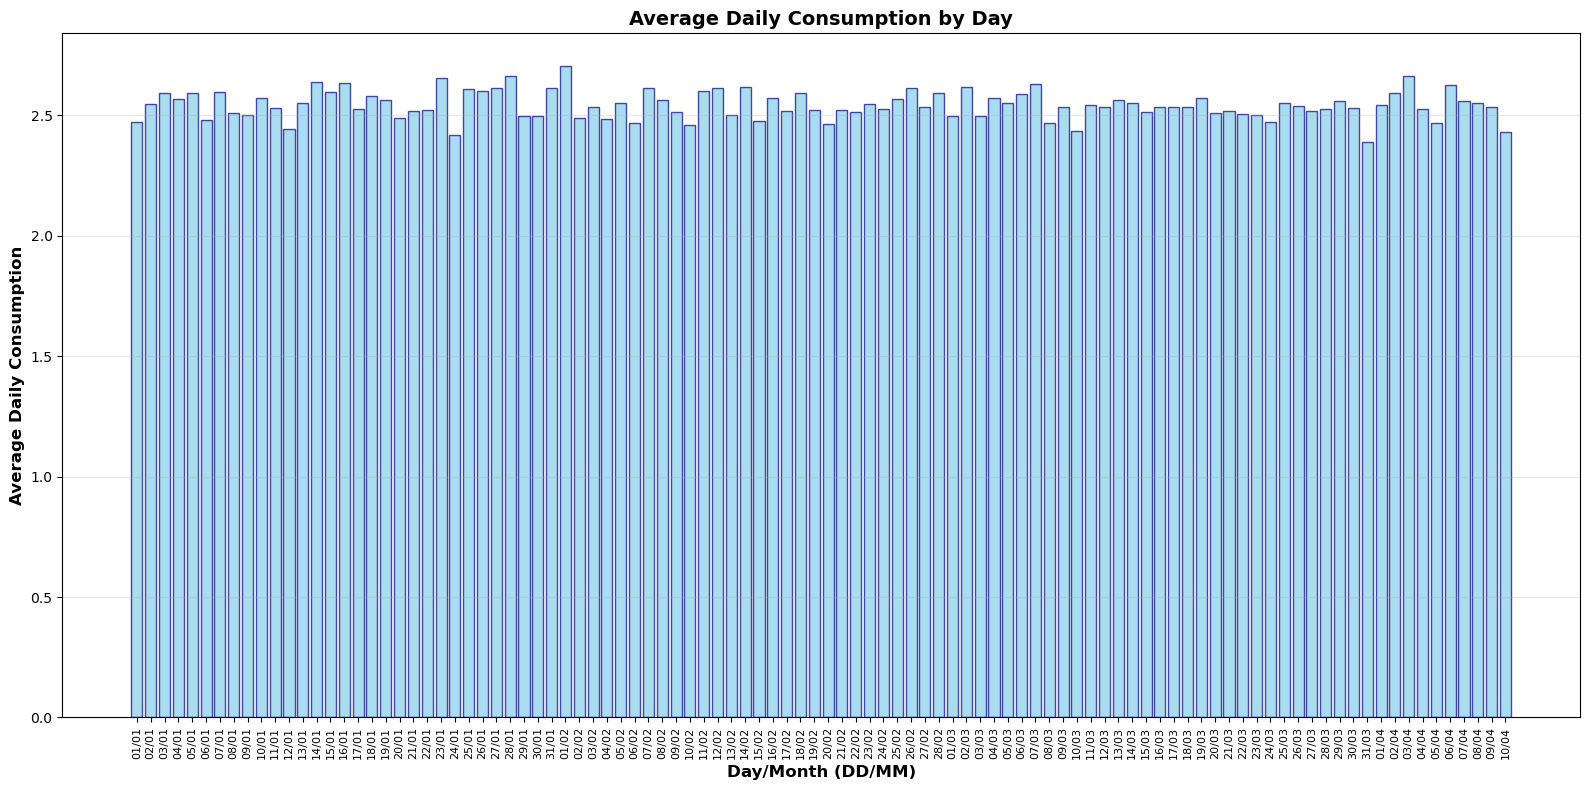

In [36]:
# Plot 2: Bar plot with day/month on x-axis
plt.figure(figsize=(16, 8))
plt.bar(earlydata['day_month'], earlydata['daily_consumption_load'], 
        color='skyblue', alpha=0.7, edgecolor='navy')

plt.xlabel('Day/Month (DD/MM)', fontsize=12, fontweight='bold')
plt.ylabel('Average Daily Consumption', fontsize=12, fontweight='bold')
plt.title('Average Daily Consumption by Day', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

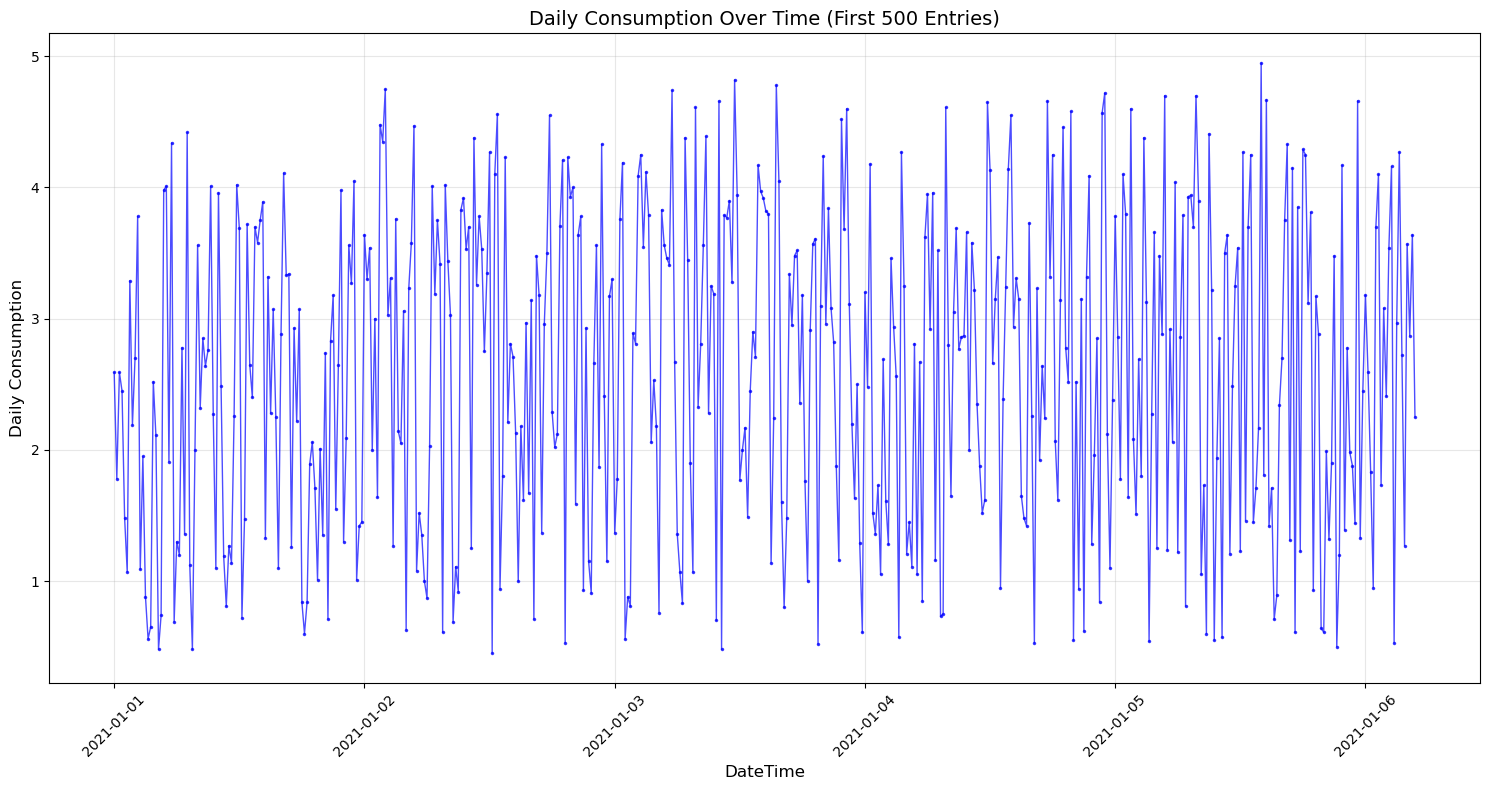

In [30]:
df_first_500 = df.head(500)

# Create the line plot
plt.figure(figsize=(15, 8))
plt.plot(df_first_500['datetime'], df_first_500['daily_consumption_load'], 
         linewidth=1, marker='.', markersize=3, color='blue', alpha=0.7)

# Customize the plot
plt.xlabel('DateTime', fontsize=12)
plt.ylabel('Daily Consumption', fontsize=12)
plt.title('Daily Consumption Over Time (First 500 Entries)', fontsize=14)
plt.grid(True, alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

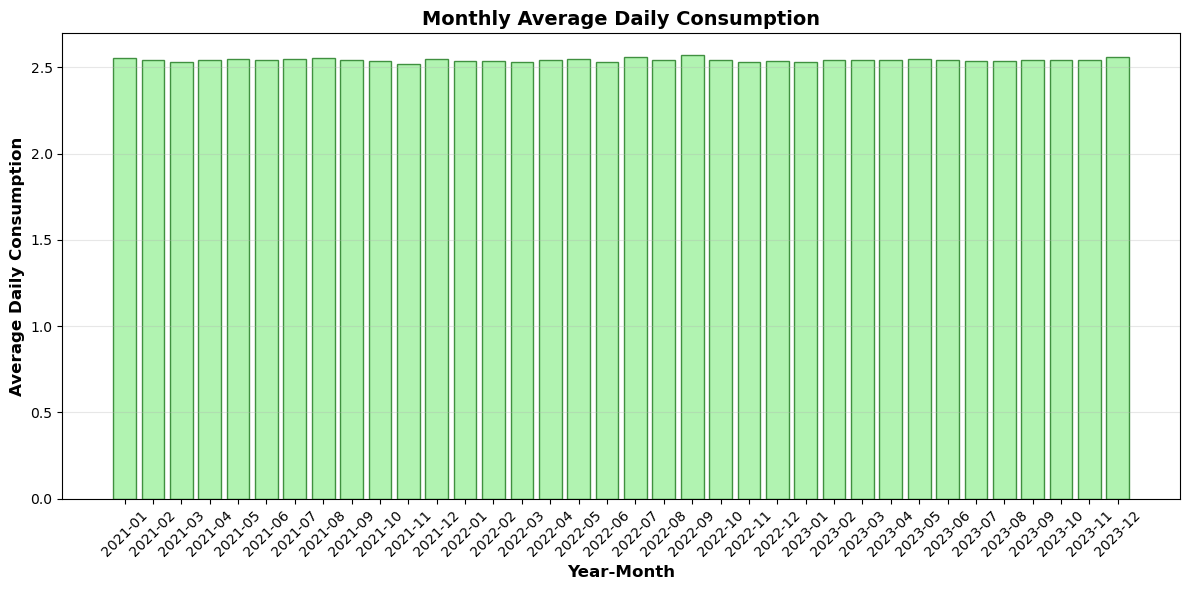

In [38]:
# Additional: Monthly average consumption
monthly_avg = df.groupby(['year', 'month'])['daily_consumption_load'].mean().reset_index()
monthly_avg['year_month'] = monthly_avg['year'].astype(str) + '-' + monthly_avg['month'].astype(str).str.zfill(2)

plt.figure(figsize=(12, 6))
plt.bar(monthly_avg['year_month'], monthly_avg['daily_consumption_load'], 
        color='lightgreen', alpha=0.7, edgecolor='darkgreen')

plt.xlabel('Year-Month', fontsize=12, fontweight='bold')
plt.ylabel('Average Daily Consumption', fontsize=12, fontweight='bold')
plt.title('Monthly Average Daily Consumption', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
import seaborn as sns

In [4]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [28]:
sns.lineplot(x=df[['datetime']][:500],y=df[['daily_consumption_load']][:500])

ValueError: If using all scalar values, you must pass an index

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   datetime                525600 non-null  datetime64[ns]
 1   msn                     525600 non-null  object        
 2   location                525600 non-null  object        
 3   daily_consumption_load  525600 non-null  float64       
 4   energy_supplied         525600 non-null  float64       
 5   energy_billed           525600 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 24.1+ MB


In [6]:
df.location.unique()

array(['Chennai', 'Delhi', 'Bengaluru', 'Kolkata', 'Mumbai'], dtype=object)

In [7]:
df.msn.unique()

array(['ACE43B7D', '7F6ACD62', '0653DAA9', '344684B5', '3F42A75F'],
      dtype=object)

In [8]:
import matplotlib.pyplot as plt


In [9]:
from sklearn.cluster import KMeans
#kmean = KMeans()

Text(0, 0.5, 'WESS')

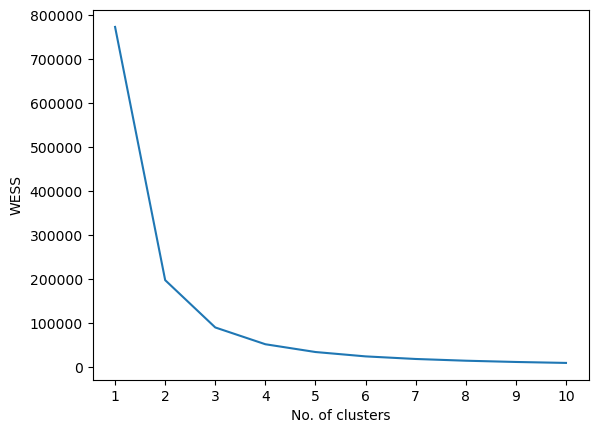

In [11]:
WESS = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i , init='k-means++')
    kmeans.fit(df[['daily_consumption_load']])
    WESS.append(kmeans.inertia_)

plt.plot(range(1,11),WESS)
plt.xticks(range(1,11))
plt.xlabel("No. of clusters")
plt.ylabel("WESS")

### this data can be seprated into 3 segments - low usage , mid usage and high usage

In [13]:
from sklearn.preprocessing import StandardScaler

In [18]:

X = df[['daily_consumption_load']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)


In [ ]:


df['cluster'] = clusters


print("Data with cluster assignments:")
print(df[['datetime', 'daily_consumption_load', 'cluster']])


cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
print("\nCluster centers (original scale):")
for i, center in enumerate(cluster_centers_original):
    print(f"Cluster {i}: {center[0]:.2f}")


Data with cluster assignments:
                  datetime  daily_consumption_load  cluster
0      2021-01-01 00:00:00                    2.59        0
1      2021-01-01 00:15:00                    1.78        1
2      2021-01-01 00:30:00                    2.59        0
3      2021-01-01 00:45:00                    2.45        0
4      2021-01-01 01:00:00                    1.48        1
...                    ...                     ...      ...
525595 2023-12-31 22:45:00                    3.38        2
525596 2023-12-31 23:00:00                    0.54        1
525597 2023-12-31 23:15:00                    1.29        1
525598 2023-12-31 23:30:00                    2.34        0
525599 2023-12-31 23:45:00                    2.93        0

[525600 rows x 3 columns]

Cluster centers (original scale):
Cluster 0: 2.57
Cluster 1: 1.17
Cluster 2: 3.97


<Figure size 1000x600 with 0 Axes>

d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


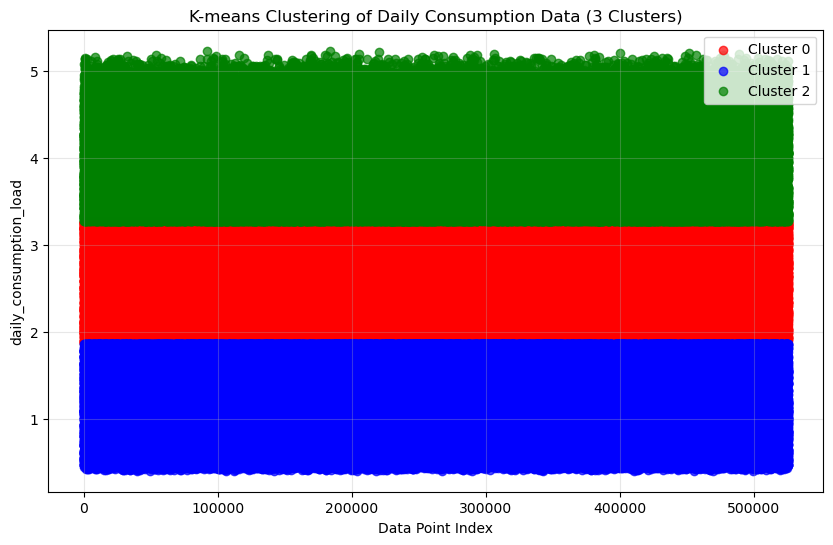

In [24]:


plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green']

for cluster_num in range(3):
    cluster_data = df[df['cluster'] == cluster_num]
    plt.scatter(cluster_data.index, cluster_data['daily_consumption_load'], 
                c=colors[cluster_num], label=f'Cluster {cluster_num}', alpha=0.7)

plt.xlabel('Data Point Index')
plt.ylabel('daily_consumption_load')
plt.title('K-means Clustering of Daily Consumption Data (3 Clusters)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()